In [1]:
using DMUStudent.HW3: HW3, DenseGridWorld, visualize_tree
using POMDPs: actions, @gen, isterminal, discount, statetype, actiontype, simulate, states, initialstate
using D3Trees: inchrome, inbrowser
using StaticArrays: SA
using Statistics
using BenchmarkTools: @btime
using POMDPTools


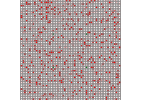

In [2]:
mdp = HW3.DenseGridWorld(seed=4)
render(mdp)

In [14]:
# Question 2:

function rollout(mdp, policy_function, s0, max_steps=100)
    
    r_total = 0.0
    t = 0
    s = s0

    while !isterminal(mdp, s) && t < max_steps
        a = policy_function(mdp, s)
        s, r = @gen(:sp,:r)(mdp, s, a)
        r_total += r
        t += 1
    end

    return r_total
end

function random_policy(mdp, s)
    return rand(actions(mdp))
end

random_policy (generic function with 1 method)

In [1]:
using DMUStudent.HW3: HW3, DenseGridWorld, visualize_tree
using POMDPs
using D3Trees: inchrome, inbrowser
using StaticArrays: SA
using Statistics
using BenchmarkTools: @btime
using POMDPTools
using Distributions: support


## Questions 2:

mdp = HW3.DenseGridWorld(seed=3)

# Questions 2.a:
function rollout(mdp, policy_function, s0, max_steps=100)

    r_total = 0.0
    t = 0
    s = s0

    while !isterminal(mdp, s) && t < max_steps
        a = policy_function(mdp, s)
        s, r = @gen(:sp, :r)(mdp, s, a)
        r_total += r
        t += 1
    end

    return r_total
end

function random_policy(mdp, s)
    return rand(actions(mdp))
end


# results = [rollout(mdp, random_policy, rand(initialstate(mdp))) for _ in 1:5000]
# @show random_p_mean_results = mean(results)
# @show random_p_SEM_results = std(results) / sqrt(length(results))

# Question 2.b

function heuristic_policy(mdp, s)
    max_a = nothing
    max_r = -Inf
    for a in actions(mdp)
        _, r = @gen(:sp, :r)(mdp, s, a)
        if r > max_r
            max_r = r
            max_a = a
        end
    end

    return max_a
end

# results = [rollout(mdp, heuristic_policy, rand(initialstate(mdp))) for _ in 1:5000]
# @show heuristic_p_mean_results = mean(results)
# @show heuristic_p_SEM_results = std(results) / sqrt(length(results))

## Question 3:  

struct MonteCarloTreeSearch
    mdp::HW3.DenseGridWorld
    N::Dict{Tuple{Any,Any},Int}
    Q::Dict{Tuple{Any,Any},Float64}
    T::Dict{Tuple{Any,Any,Any},Int}
    d::Int
    m::Int
    c::Float64
end

function MonteCarloTreeSearch(mdp::HW3.DenseGridWorld, d::Int=10, m::Int=7, c::Float64=100.0)
    S = statetype(mdp)
    A = actiontype(mdp)
    N = Dict{Tuple{S,A},Int}()
    Q = Dict{Tuple{S,A},Float64}()
    T = Dict{Tuple{S,A,S},Int}()
    return MonteCarloTreeSearch(mdp, N, Q, T, d, m, c)
end

function explore(mcts::MonteCarloTreeSearch, s::Any)
    for a in actions(mcts.mdp)
        if mcts.N[(s, a)] == 0
            return a
        end
    end
    Ns = sum([mcts.N[(s, a)] for a in actions(mcts.mdp)])
    a_ind = argmax([mcts.Q[(s, a)] + mcts.c * sqrt(log(Ns) / mcts.N[(s, a)]) for a in actions(mcts.mdp)])
    return actions(mcts.mdp)[a_ind]
end

function simulate!(mcts::MonteCarloTreeSearch, s::Any, d::Int)
    if d <= 0
        return sum([mcts.Q[(s, a)] for a in actions(mcts.mdp)])
    end

    if !haskey(mcts.N, (s, actions(mcts.mdp)[1]))
        for a in actions(mcts.mdp)
            mcts.N[(s, a)] = 0
            mcts.Q[(s, a)] = 0.0
        end
        return sum([mcts.Q[(s, a)] for a in actions(mcts.mdp)])
    end

    a = explore(mcts, s)
    sp, r = @gen(:sp, :r)(mcts.mdp, s, a)
    q = r + discount(mcts.mdp) * simulate!(mcts, sp, d - 1)
    mcts.N[(s, a)] += 1
    if !haskey(mcts.T, (s, a, sp))
        mcts.T[(s, a, sp)] = 0
    end
    mcts.T[(s, a, sp)] += 1
    mcts.Q[(s, a)] += (q - mcts.Q[(s, a)]) / mcts.N[(s, a)]
    return q
end

function (mcts::MonteCarloTreeSearch)(s::Any)
    for k in 1:mcts.m
        simulate!(mcts, s, mcts.d)
    end
    inchrome(visualize_tree(mcts.Q, mcts.N, mcts.T, s))
end

mdp = HW3.DenseGridWorld()
mcts = MonteCarloTreeSearch(mdp)
mcts(SA[19, 19])


[56772:56772:0219/144924.149789:ERROR:ozone_platform_x11.cc(245)] Missing X server or $DISPLAY
[56772:56772:0219/144924.149807:ERROR:env.cc(257)] The platform failed to initialize.  Exiting.


ProcessFailedException: failed process: Process(`google-chrome /tmp/jl_IE4xKS/tree.html`, ProcessExited(1)) [1]
